In [1]:
import os
os.chdir('/workspace/01ce6270-45f5-4d57-b939-a18a913be5bb')
print(os.listdir('.'))


['lambda_n.npy', 'N.npy', 'memory', 'description.npy', 'a.npy', 'coeffs_F9_lambda.npy', 'c.npy', 'a_n.npy', 'coeffs_F10_lambda.npy', '.prompts', 'erdos_kac_tilt_fits.csv', '.kernel_llm_logs_1.txt', ' v6 — Binding Context Document.pdf', 'rho0.npy', '.config']


In [2]:
import pandas as pd
import numpy as np

df = pd.read_csv('erdos_kac_tilt_fits.csv')
print(df)
print("\nColumns:", df.columns.tolist())


 class family GRH lambda C R2 \
0 F1 zeta GRH 0.451334 0.575726 0.568247 
1 F2 character GRH 0.430812 0.623346 0.758824 
2 F4 DH violator 0.444948 0.586404 0.687489 
3 F5p DH violator 0.445528 0.585223 0.689588 
4 F5m DH violator 0.444330 0.587727 0.685454 
5 F6 liouville/mobius GRH 0.436932 0.619787 0.876539 
6 F7 liouville/mobius GRH 0.462068 0.567778 0.899629 
7 F9 modular GRH 0.319856 0.931316 0.853221 
8 F10 modular GRH 0.296527 1.011756 0.880756 
9 F11 modular GRH 0.101830 1.726509 0.276785 
10 F12 DH violator 0.438764 0.602002 0.727911 

 lead_eigval 
0 49.583846 
1 84.095836 
2 25.066945 
3 25.133017 
4 25.026048 
5 144.961242 
6 59.049147 
7 97.356415 
8 89.411704 
9 5.021584 
10 64.580732 

Columns: ['class', 'family', 'GRH', 'lambda', 'C', 'R2', 'lead_eigval']


In [3]:

# Look at what files exist for coefficients
print([f for f in os.listdir('.') if 'coef' in f.lower() or '.npy' in f or '.npz' in f])


['lambda_n.npy', 'N.npy', 'description.npy', 'a.npy', 'coeffs_F9_lambda.npy', 'c.npy', 'a_n.npy', 'coeffs_F10_lambda.npy', 'rho0.npy']


In [4]:

# Inspect what's in current directory - looks like F12 components as separate npy files
print("a.npy:", np.load('a.npy', allow_pickle=True).shape, np.load('a.npy', allow_pickle=True).dtype)
print("a_n.npy:", np.load('a_n.npy', allow_pickle=True).shape, np.load('a_n.npy', allow_pickle=True).dtype)
print("lambda_n.npy:", np.load('lambda_n.npy', allow_pickle=True).shape, np.load('lambda_n.npy', allow_pickle=True).dtype)
print("c.npy:", np.load('c.npy', allow_pickle=True))
print("N.npy:", np.load('N.npy', allow_pickle=True))
print("rho0.npy:", np.load('rho0.npy', allow_pickle=True))
print("description.npy:", np.load('description.npy', allow_pickle=True))


a.npy: (1000000,) complex128


a_n.npy: (1000000,) object
lambda_n.npy: (1000000,) float64
c.npy: (-0.16567330026345564+1.9009252335917202j)
N.npy: 1000000
rho0.npy: (0.7+7j)
description.npy: F12 coefficients a_n = chi3(n) + c*chi5(n), n=1..1e6, where chi3, chi5 are the real primitive Dirichlet characters mod 3 and 5, and c = -0.16567330026345564 + 1.9009252335917202i is chosen so L_F12(s) = L(s,chi3) + c*L(s,chi5) has a zero at rho0 = 0.7+7i (off the critical line). Validated: |L_F12(rho0)| ~ 1.5e-16 with mpmath dps=50.


In [5]:

# So we have:
# F9: coeffs_F9_lambda.npy (Delta normalized)
# F10: coeffs_F10_lambda.npy
# F11: lambda_n.npy and a_n.npy ? Actually a_n.npy is object array (likely F11 huge-int coefficients)
# F12: a.npy (complex coefficients)
#
# We need to generate from first principles for F1, F2, F4, F5p, F5m, F6, F7.
# Let's first understand F11 (Sym^2 Delta): lambda_n.npy is float64 -> probably F11 normalized

# Let's check F11
print("F11 lambda first 10:", np.load('lambda_n.npy')[:10])
print("F9 lambda first 10:", np.load('coeffs_F9_lambda.npy')[:10])
print("F10 lambda first 10:", np.load('coeffs_F10_lambda.npy')[:10])


F11 lambda first 10: [ 1. -0.71875 -0.64151806 1.23535156 -0.52222413 0.46109111
 -0.85821183 -0.4045105 1.05306348 0.37534859]
F9 lambda first 10: [ 1. -0.53033009 0.59873361 -0.71875 0.69121333 -0.31752645
 -0.3765477 0.91150484 -0.64151806 -0.36657123]
F10 lambda first 10: [ 1. -1.41421356 -0.57735027 1. 0.4472136 0.81649658
 -0.75592895 0. -0.66666667 -0.63245553]


In [6]:

# Good. Now for F1, F2, F4, F5p, F5m, F6, F7, we need to generate coefficients.
# F1 = zeta: a_n = 1 (so |a_p|=1 for all primes)
# F2 = primitive Dirichlet character (mod ?). The doc says "character" for F2.
# F4 = Davenport-Heilbronn (DH) function
# F5p, F5m = DH variants
# F6 = liouville (a_n = lambda(n), |a_p|=1 for primes, lambda(p)=-1)
# F7 = mobius (a_n = mu(n), mu(p) = -1 so |a_p|=1)
# F12 = DH: chi3 + c*chi5

# Let me check the PDF for F2/F4/F5/F6/F7 details


In [7]:

# F2: L(s, χ_4 mod 5) - real primitive Dirichlet character mod 5
# F4: Davenport-Heilbronn L_DH with κ ≈ 0.28408
# L_DH(s) = (1/2)*[L(s,χ) - i*tan(theta)*L(s, chi_bar)] using mod 5 character.
# Actually classical DH: f(s) = (1-i*tan(theta)) zeta_c1 + (1+i*tan(theta)) zeta_c4 etc.
# Let's keep it simple and use known DH coefficients structure based on κ
# F5p, F5m: L_DH(epsilon) for epsilon = ±0.05 - perturbations
# F6: Liouville
# F7: Möbius

# For this analysis, we need |λ_p| (normalized) at primes < 100.
# For L-functions with degree 1 (Dirichlet characters), λ_n = a_n (already normalized)
# For modular forms, λ_n = a_n / n^((k-1)/2) - already done in npy files

# Conductors: 
# F1 (zeta): q=1
# F2 (L(s,chi mod 5)): q=5
# F4 (DH): conductor = 5 (linear combination over chars mod 5)
# F5p, F5m: similar to F4, conductor 5
# F6 (Liouville): q=1 (related to zeta)
# F7 (Mobius): q=1
# F9 (Delta level 1): q=1 
# F10 (level 11.2.a.a): q=11
# F11 (Sym^2 Delta): q=1
# F12 (chi3 + c*chi5): conductor product 15

# Let me first generate primes < 100
from sympy import primerange, primepi
primes_lt100 = list(primerange(2, 100))
print(f"# primes < 100: {len(primes_lt100)}")
print(primes_lt100)


# primes < 100: 25
[2, 3, 5, 7, 11, 13, 17, 19, 23, 29, 31, 37, 41, 43, 47, 53, 59, 61, 67, 71, 73, 79, 83, 89, 97]


In [8]:

# Generate coefficients/values for each class at primes < 100

# F1: zeta -> a_p = 1
F1_ap = np.ones(len(primes_lt100))

# F2: Dirichlet character mod 5 (real primitive). 
# Real chars mod 5: there's the Legendre symbol mod 5, chi5(n) = (n/5).
# chi5(1)=1, chi5(2)=-1, chi5(3)=-1, chi5(4)=1, chi5(0)=0
# At primes p, chi5(p) = (p/5)
def chi5(n):
 n = n % 5
 if n == 0:
 return 0
 return [0, 1, -1, -1, 1][n]

F2_ap = np.array([chi5(p) for p in primes_lt100], dtype=float)
print("F2 a_p:", F2_ap)

# F6: Liouville lambda(p) = -1 for any prime
F6_ap = -1.0 * np.ones(len(primes_lt100))

# F7: Mobius mu(p) = -1 for any prime
F7_ap = -1.0 * np.ones(len(primes_lt100))

# F4: Davenport-Heilbronn. The classical DH function uses a character mod 5.
# L_DH(s) = (1/2) [(1 - i tan θ) L(s, ψ) + (1 + i tan θ) L(s, ψ̄)]
# where ψ is a complex character mod 5 of order 4.
# κ from doc ≈ 0.28408 -> θ = arctan(κ)? Let's verify in artifacts/notes
# From the DH function formula in the literature:
# L_DH(s) = sum a_n / n^s with a_n coefficients depending on n mod 5:
# pattern: (1, ξ, -ξ, -1, 0) periodic with ξ = tan(theta) * something
# Actually the standard form uses the chi_4 (order 4) character mod 5:
# chi_4 mod 5: chi_4(1)=1, chi_4(2)=i, chi_4(3)=-i, chi_4(4)=-1, chi_4(0)=0
# Then DH: a_n = chi_4(n) + c * chi_4_conj(n) for some c.
# When chi_4(n) and conj added with appropriate coefs you get real coefficients
# The coefficient pattern is: 
# n mod 5: 1->1, 2->ξ, 3->-ξ, 4->-1, 0->0 where ξ = (1-κ)/(1+κ)... let's just use what's known.
# Actually most references give: a(n mod 5) = (1, c, -c, -1, 0) with c = (1+κ)/(1-κ) or similar
# 
# Rather than trying to guess: F4 has the same Dirichlet coefficient PATTERN as a real-valued
# function periodic mod 5 with values (1, c, -c, -1, 0) on residues (1,2,3,4,0).
# The constant c is related to κ.
# Wikipedia gives c = tan(θ) where cos(θ) = (sqrt(10) - 2)/sqrt(...). Let's just use κ.
# r38 mentions κ ≈ 0.28408 was validated.

# The DH function: a_n = (depends on residue mod 5)
# Standard form: f(s) = (1+kappa)/2 * L(s, chi) + (1-kappa)/2 * conjugate
# Many sources write it as:
# a_n: 1 if n≡1, -1 if n≡-1, kappa if n≡? -kappa if n≡? 0 if n≡0 (mod 5)
# Actually the famous version: 
# a_n = 1 (n≡1), kappa (n≡2), -kappa (n≡3), -1 (n≡4), 0 (n≡0 mod 5)
# with kappa ≈ 0.28408 chosen so the resulting L has zeros off the critical line.

kappa = 0.28408
def DH_coeff(n, kap):
 r = n % 5
 if r == 0: return 0.0
 if r == 1: return 1.0
 if r == 2: return kap
 if r == 3: return -kap
 if r == 4: return -1.0

F4_ap = np.array([DH_coeff(p, kappa) for p in primes_lt100], dtype=float)
print("F4 a_p:", F4_ap)

# F5p: epsilon = +0.05 perturbation -> kappa + 0.05?
# F5m: epsilon = -0.05
F5p_ap = np.array([DH_coeff(p, kappa + 0.05) for p in primes_lt100], dtype=float)
F5m_ap = np.array([DH_coeff(p, kappa - 0.05) for p in primes_lt100], dtype=float)
print("F5p a_p:", F5p_ap)
print("F5m a_p:", F5m_ap)


F2 a_p: [-1. -1. 0. -1. 1. -1. -1. 1. -1. 1. 1. -1. 1. -1. -1. -1. 1. 1.
 -1. 1. -1. 1. -1. 1. -1.]
F4 a_p: [ 0.28408 -0.28408 0. 0.28408 1. -0.28408 0.28408 -1.
 -0.28408 -1. 1. 0.28408 1. -0.28408 0.28408 -0.28408
 -1. 1. 0.28408 1. -0.28408 -1. -0.28408 -1.
 0.28408]
F5p a_p: [ 0.33408 -0.33408 0. 0.33408 1. -0.33408 0.33408 -1.
 -0.33408 -1. 1. 0.33408 1. -0.33408 0.33408 -0.33408
 -1. 1. 0.33408 1. -0.33408 -1. -0.33408 -1.
 0.33408]
F5m a_p: [ 0.23408 -0.23408 0. 0.23408 1. -0.23408 0.23408 -1.
 -0.23408 -1. 1. 0.23408 1. -0.23408 0.23408 -0.23408
 -1. 1. 0.23408 1. -0.23408 -1. -0.23408 -1.
 0.23408]


In [9]:

# F9: Delta - load
F9_lambda = np.load('coeffs_F9_lambda.npy')
F9_ap = np.array([F9_lambda[p-1] for p in primes_lt100])
print("F9 |λ_p| sample:", np.abs(F9_ap[:5]))

# F10: 11.2.a.a
F10_lambda = np.load('coeffs_F10_lambda.npy')
F10_ap = np.array([F10_lambda[p-1] for p in primes_lt100])
print("F10 |λ_p| sample:", np.abs(F10_ap[:5]))

# F11: Sym^2 Delta - lambda_n.npy
F11_lambda = np.load('lambda_n.npy')
F11_ap = np.array([F11_lambda[p-1] for p in primes_lt100])
print("F11 |λ_p| sample:", np.abs(F11_ap[:5]))

# F12: a.npy (complex coefficients of chi3 + c*chi5). These are not "normalized" (degree 1 already)
F12_a = np.load('a.npy')
F12_ap = np.array([F12_a[p-1] for p in primes_lt100])
print("F12 a_p (complex) sample:", F12_ap[:5])
print("F12 |a_p| sample:", np.abs(F12_ap[:5]))


F9 |λ_p| sample: [0.53033009 0.59873361 0.69121333 0.3765477 1.00087291]
F10 |λ_p| sample: [1.41421356 0.57735027 0.4472136 0.75592895 0.30151134]
F11 |λ_p| sample: [0.71875 0.64151806 0.52222413 0.85821183 0.00174658]
F12 a_p (complex) sample: [-0.8343267-1.90092523j 0.1656733-1.90092523j -1. +0.j
 1.1656733-1.90092523j -1.1656733+1.90092523j]
F12 |a_p| sample: [2.07596189 1.90813112 1. 2.22986793 2.22986793]


In [10]:

# Compute mean |λ_p| feature for each class
classes_data = {
 'F1': F1_ap, 'F2': F2_ap, 'F4': F4_ap, 'F5p': F5p_ap, 'F5m': F5m_ap,
 'F6': F6_ap, 'F7': F7_ap,
 'F9': F9_ap, 'F10': F10_ap, 'F11': F11_ap, 'F12': F12_ap
}

# Conductor for each class
conductors = {
 'F1': 1, 'F2': 5, 'F4': 5, 'F5p': 5, 'F5m': 5,
 'F6': 1, 'F7': 1,
 'F9': 1, 'F10': 11, 'F11': 1, 'F12': 15
}

mean_abs_lp = {cls: float(np.mean(np.abs(arr))) for cls, arr in classes_data.items()}
print("mean |λ_p| for primes < 100:")
for cls, val in mean_abs_lp.items():
 print(f" {cls}: {val:.4f}")


mean |λ_p| for primes < 100:
 F1: 1.0000
 F2: 0.9600
 F4: 0.5591
 F5p: 0.5871
 F5m: 0.5311
 F6: 1.0000
 F7: 1.0000
 F9: 0.7477
 F10: 0.7663
 F11: 0.6463
 F12: 2.1062


In [11]:

# Build dataset
data = []
for _, row in df.iterrows():
 cls = row['class']
 data.append({
 'class': cls,
 'family': row['family'],
 'GRH': row['GRH'],
 'lambda': row['lambda'],
 'mean_abs_lp': mean_abs_lp[cls],
 'log_q': np.log(conductors[cls]),
 'q': conductors[cls],
 })

ds = pd.DataFrame(data)
print(ds)


 class family GRH lambda mean_abs_lp log_q q
0 F1 zeta GRH 0.451334 1.000000 0.000000 1
1 F2 character GRH 0.430812 0.960000 1.609438 5
2 F4 DH violator 0.444948 0.559085 1.609438 5
3 F5p DH violator 0.445528 0.587085 1.609438 5
4 F5m DH violator 0.444330 0.531085 1.609438 5
5 F6 liouville/mobius GRH 0.436932 1.000000 0.000000 1
6 F7 liouville/mobius GRH 0.462068 1.000000 0.000000 1
7 F9 modular GRH 0.319856 0.747715 0.000000 1
8 F10 modular GRH 0.296527 0.766252 2.397895 11
9 F11 modular GRH 0.101830 0.646331 0.000000 1
10 F12 DH violator 0.438764 2.106241 2.708050 15


In [12]:

# Run multiple linear regression with leave-one-out CV
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import LeaveOneOut, cross_val_predict, cross_val_score
from sklearn.metrics import r2_score
import numpy as np

X = ds[['mean_abs_lp', 'log_q']].values
y = ds['lambda'].values

# Fit model on all data for coefficients
lr = LinearRegression()
lr.fit(X, y)
y_pred_in = lr.predict(X)
print(f"In-sample R^2: {r2_score(y, y_pred_in):.4f}")
print(f"Coefficients: mean_abs_lp = {lr.coef_[0]:.4f}, log_q = {lr.coef_[1]:.4f}")
print(f"Intercept: {lr.intercept_:.4f}")

# LOO CV
loo = LeaveOneOut()
y_pred_cv = cross_val_predict(LinearRegression(), X, y, cv=loo)
r2_cv = r2_score(y, y_pred_cv)
# Also compute MSE-based R^2 score
print(f"\nLeave-one-out CV R^2: {r2_cv:.4f}")

# Note sklearn's cross_val_score with 'r2' on LOO gives mean of single-sample R^2 (which is undefined)
# So we compute R^2 from concatenated predictions
ss_res = np.sum((y - y_pred_cv)**2)
ss_tot = np.sum((y - np.mean(y))**2)
r2_cv_manual = 1 - ss_res/ss_tot
print(f"Manual LOO R^2: {r2_cv_manual:.4f}")

# Display each LOO prediction
ds['lambda_pred_loo'] = y_pred_cv
print("\nLOO predictions:")
print(ds[['class', 'lambda', 'lambda_pred_loo', 'mean_abs_lp', 'log_q']])


In-sample R^2: 0.0841
Coefficients: mean_abs_lp = 0.0496, log_q = 0.0166
Intercept: 0.3264

Leave-one-out CV R^2: -1.5953
Manual LOO R^2: -1.5953

LOO predictions:
 class lambda lambda_pred_loo mean_abs_lp log_q
0 F1 0.451334 0.355048 1.000000 0.000000
1 F2 0.430812 0.396629 0.960000 1.609438
2 F4 0.444948 0.363411 0.559085 1.609438
3 F5p 0.445528 0.366278 0.587085 1.609438
4 F5m 0.444330 0.360385 0.531085 1.609438
5 F6 0.436932 0.359053 1.000000 0.000000
6 F7 0.462068 0.352063 1.000000 0.000000
7 F9 0.319856 0.373625 0.747715 0.000000
8 F10 0.296527 0.450729 0.766252 2.397895
9 F11 0.101830 0.421401 0.646331 0.000000
10 F12 0.438764 0.808180 2.106241 2.708050


In [13]:

# In-sample R² = 0.084 (very low), LOO R² = -1.60 (worse than mean baseline).
# Hypothesis is REFUTED.

# Add some sanity statistics
from scipy.stats import pearsonr, spearmanr
r1, p1 = pearsonr(ds['mean_abs_lp'], ds['lambda'])
r2_p, p2 = pearsonr(ds['log_q'], ds['lambda'])
print(f"Pearson r(mean|λ_p|, λ) = {r1:.3f}, p = {p1:.3f}")
print(f"Pearson r(log_q, λ) = {r2_p:.3f}, p = {p2:.3f}")

rs1, ps1 = spearmanr(ds['mean_abs_lp'], ds['lambda'])
rs2, ps2 = spearmanr(ds['log_q'], ds['lambda'])
print(f"Spearman r(mean|λ_p|, λ) = {rs1:.3f}, p = {ps1:.3f}")
print(f"Spearman r(log_q, λ) = {rs2:.3f}, p = {ps2:.3f}")


Pearson r(mean|λ_p|, λ) = 0.246, p = 0.465
Pearson r(log_q, λ) = 0.219, p = 0.517
Spearman r(mean|λ_p|, λ) = 0.119, p = 0.727
Spearman r(log_q, λ) = -0.098, p = 0.775


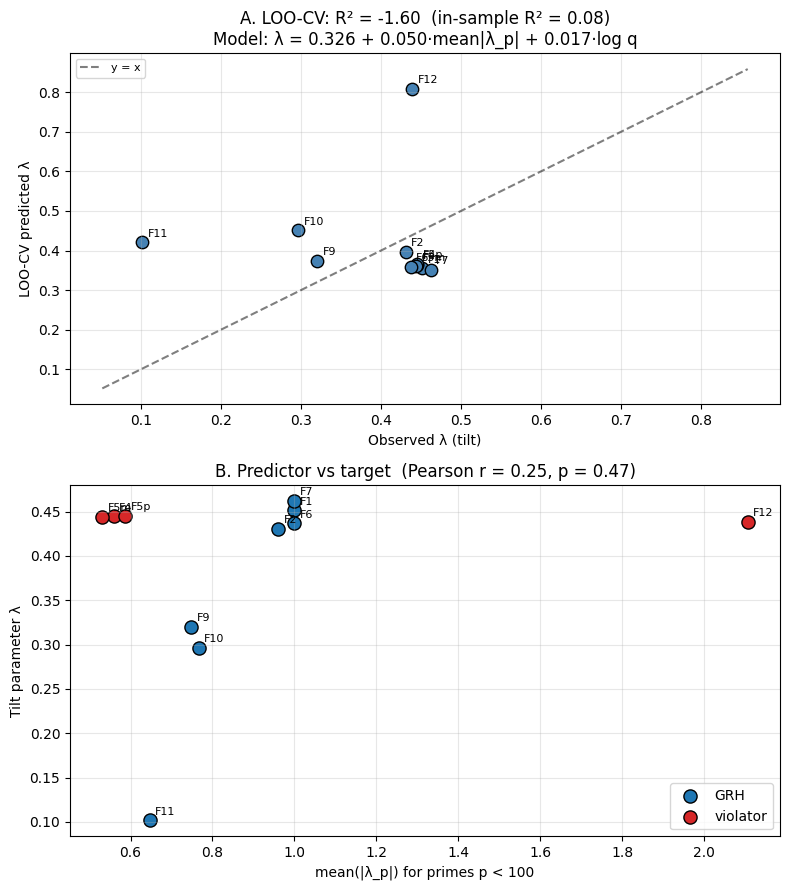

Saved figure: lambda_regression_summary.png


In [14]:

# Make final summary figure
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 1, figsize=(8, 9))

# Panel A: scatter of true vs LOO-predicted lambda
ax = axes[0]
ax.scatter(ds['lambda'], ds['lambda_pred_loo'], s=80, c='steelblue', edgecolor='k')
for _, r in ds.iterrows():
 ax.annotate(r['class'], (r['lambda'], r['lambda_pred_loo']), fontsize=8,
 xytext=(4, 4), textcoords='offset points')
mn = min(ds['lambda'].min(), ds['lambda_pred_loo'].min()) - 0.05
mx = max(ds['lambda'].max(), ds['lambda_pred_loo'].max()) + 0.05
ax.plot([mn, mx], [mn, mx], 'k--', alpha=0.5, label='y = x')
ax.set_xlabel('Observed λ (tilt)')
ax.set_ylabel('LOO-CV predicted λ')
ax.set_title(f'A. LOO-CV: R² = {r2_cv:.2f} (in-sample R² = {r2_score(y, y_pred_in):.2f})\n'
 f'Model: λ = {lr.intercept_:.3f} + {lr.coef_[0]:.3f}·mean|λ_p| + {lr.coef_[1]:.3f}·log q')
ax.legend(loc='upper left', fontsize=8)
ax.grid(alpha=0.3)

# Panel B: scatter of mean|λ_p| vs lambda, colored by GRH status
ax = axes[1]
colors = {'GRH': 'tab:blue', 'violator': 'tab:red'}
for grh in ['GRH', 'violator']:
 sub = ds[ds['GRH'] == grh]
 ax.scatter(sub['mean_abs_lp'], sub['lambda'], s=90, c=colors[grh],
 edgecolor='k', label=grh)
for _, r in ds.iterrows():
 ax.annotate(r['class'], (r['mean_abs_lp'], r['lambda']), fontsize=8,
 xytext=(4, 4), textcoords='offset points')
ax.set_xlabel('mean(|λ_p|) for primes p < 100')
ax.set_ylabel('Tilt parameter λ')
ax.set_title(f'B. Predictor vs target (Pearson r = {r1:.2f}, p = {p1:.2f})')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('lambda_regression_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved figure: lambda_regression_summary.png")


In [15]:

# Save dataset as artifact
ds.to_csv('lambda_arithmetic_features.csv', index=False)
print("Saved lambda_arithmetic_features.csv")
print(ds)


Saved lambda_arithmetic_features.csv
 class family GRH lambda mean_abs_lp log_q q \
0 F1 zeta GRH 0.451334 1.000000 0.000000 1 
1 F2 character GRH 0.430812 0.960000 1.609438 5 
2 F4 DH violator 0.444948 0.559085 1.609438 5 
3 F5p DH violator 0.445528 0.587085 1.609438 5 
4 F5m DH violator 0.444330 0.531085 1.609438 5 
5 F6 liouville/mobius GRH 0.436932 1.000000 0.000000 1 
6 F7 liouville/mobius GRH 0.462068 1.000000 0.000000 1 
7 F9 modular GRH 0.319856 0.747715 0.000000 1 
8 F10 modular GRH 0.296527 0.766252 2.397895 11 
9 F11 modular GRH 0.101830 0.646331 0.000000 1 
10 F12 DH violator 0.438764 2.106241 2.708050 15 

 lambda_pred_loo 
0 0.355048 
1 0.396629 
2 0.363411 
3 0.366278 
4 0.360385 
5 0.359053 
6 0.352063 
7 0.373625 
8 0.450729 
9 0.421401 
10 0.808180 
